In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pwd

In [5]:
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

In [6]:
train_transaction.head(2)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
train_identity.head(2)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device


In [8]:
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
df.shape

(590540, 434)

In [12]:
df['isFraud'].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [15]:
isfraud_counts = df['isFraud'].value_counts()
fraud_ratio = df['isFraud'].mean() 

print(f"Normal islem sayisi: {isfraud_counts[0]}")
print(f"Fraud islem sayisi: {isfraud_counts[1]}")
print(f"Fraud Orani: %{fraud_ratio*100:.2f}")

Normal islem sayisi: 569877
Fraud islem sayisi: 20663
Fraud Orani: %3.50


## Sinif Dengesizligi
#### Veri setinde fraud orani %3.5 seviyesindedir. Bu dengesiz dagilima gore metrik secimi ve model yaklasimi yapilmalidir. Accuracy metrigi yaniltici sonuclar verebilir ornegin model tum islemlere Fraud degil yani 0 olarak tahmin etse bile %96.5 dogruluk elde etmis olacagiz ama bu asiri yaniltici olacaktir cunku tum Fraud islemleri kacmis oluyor. Bu yuzden PR-AUC ve ROC-AUC metrikleri baz alinabilir. 

#### Model yaklasimi ise LGBM modelinde is_unbalance ve scale_pos_weight parametreleri aktif edilerek Fraud sinifin gradyan agirligi artirilacaktir

In [17]:
df.isnull().mean().sort_values(ascending=False).head(20)

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_03    0.887689
id_04    0.887689
D6       0.876068
id_33    0.875895
id_10    0.873123
dtype: float64

C:\Users\mehme\AppData\Local\Temp\ipykernel_84068\3988744905.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['isFraud'] == 0]['TransactionAmt'], label='Normal İşlemler', shade=True, color='blue')
C:\Users\mehme\AppData\Local\Temp\ipykernel_84068\3988744905.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['isFraud'] == 1]['TransactionAmt'], label='Fraud İşlemler', shade=True, color='red')


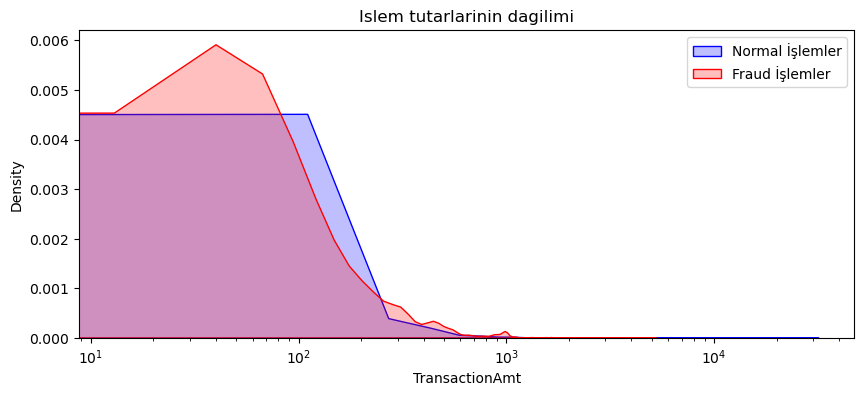

In [23]:
plt.figure(figsize=(10, 4))
sns.kdeplot(df[df['isFraud'] == 0]['TransactionAmt'], label='Normal İşlemler', shade=True, color='blue')
sns.kdeplot(df[df['isFraud'] == 1]['TransactionAmt'], label='Fraud İşlemler', shade=True, color='red')
plt.xscale('log')
plt.title('Islem tutarlarinin dagilimi')
plt.xlabel('TransactionAmt')
plt.ylabel('Density')
plt.legend()
plt.show()

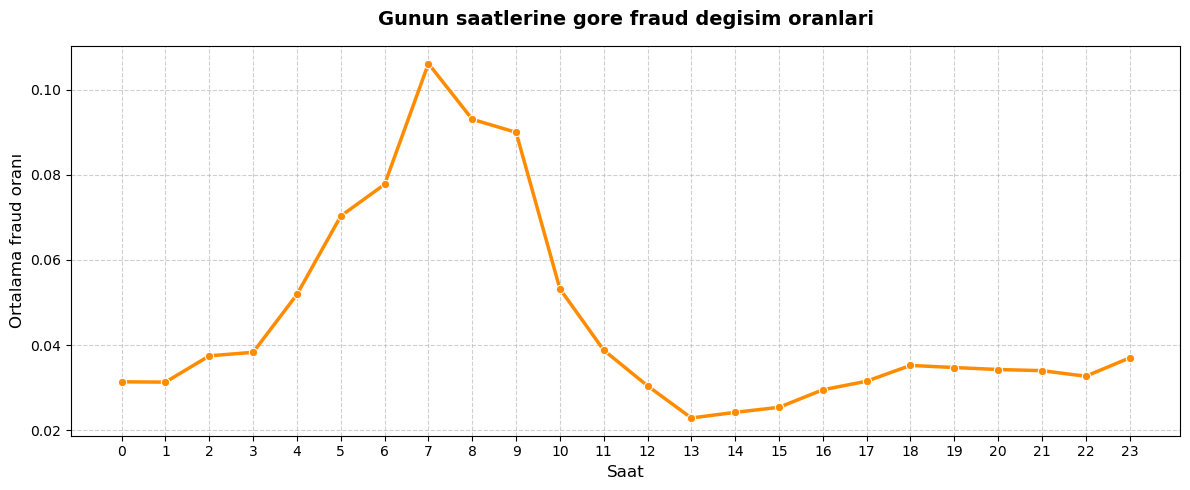

In [68]:
df['Transaction_Hour'] = ((df['TransactionDT'] / 3600) % 24).astype(int)

hourly_fraud = df.groupby('Transaction_Hour')['isFraud'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_fraud, x='Transaction_Hour', y='isFraud', color='darkorange', marker='o', linewidth=2.5)

plt.title('Gunun saatlerine gore fraud degisim oranlari', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Saat', fontsize=12)
plt.ylabel('Ortalama fraud oranı', fontsize=12)
plt.xticks(range(0, 24)) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [49]:
print("Cihaz turlerine gore fraud oranlari")
df.groupby('DeviceType')['isFraud'].agg(['count', 'mean'])

Cihaz turlerine gore fraud oranlari


,count,mean
DeviceType,,
desktop,85165,0.065215
mobile,55645,0.101662


In [31]:
print("En yuksek risk tasiyan 5 domain")
email_risk = df.groupby('R_emaildomain')['isFraud'].agg(['count', 'mean'])
email_risk[email_risk['count'] > 100].sort_values(by='mean', ascending=False).head(5)

En yuksek risk tasiyan 5 domain


,count,mean
R_emaildomain,,
mail.com,122,0.377049
outlook.com,2507,0.165138
outlook.es,433,0.131640
icloud.com,1398,0.128755
gmail.com,57147,0.119184


## Kategorik Degisken
#### Yuksek cardinality'e sahip kategorik degiskenlerde one-hot encoding kullanilmayacaktir cunku veri matrisini asiri sparse hale getirip bellek tuketimini artirir. LGBM'in native kategoruk ozellik destegine birakilabilir veya overfitting engellemek adina target encodig islemi yapilanbilir.

In [90]:
# Sistemde null olan veriler ile null olmayan veriler arasinda fraud orani acisindan anlamli bir fark var mi? 
def check_null_fraud_difference(target = 'isFraud'):
    results = []
    
    for col in df.columns:
    
        if col == target:
            continue
    
        null_ratio = df[col].isnull().mean()
    
        unique_count = df[col].nunique()
    
        if df[col].isnull().sum() > 0:
            fraud_null = df[df[col].isnull()][target].mean()
            fraud_notnull = df[df[col].notnull()][target].mean()
    
            fraud_difference = abs(fraud_null - fraud_notnull)
    
        else:
            fraud_difference = 0
    
        results.append([
            col,
            round(null_ratio, 3),
            unique_count,
            round(fraud_difference, 3)
        ])
    
    summary = pd.DataFrame(
        results,
        columns=[
            'Column',
            'Null_Ratio',
            'Unique_Count',
            'Fraud_Difference'
        ]
    )
    return summary

In [92]:
summary=check_null_fraud_difference()

In [102]:
summary.sort_values(
    by='Fraud_Difference',
    ascending=False
).head(60)

,Column,Null_Ratio,Unique_Count,Fraud_Difference
347,V294,0.000,1286,0.132
359,V306,0.000,16210,0.132
352,V299,0.000,50,0.132
355,V302,0.000,17,0.132
356,V303,0.000,21,0.132
333,V280,0.000,975,0.132
332,V279,0.000,881,0.132
374,V321,0.000,5560,0.132
348,V295,0.000,928,0.132
357,V304,0.000,17,0.132


## Yukaridaki ciktida sunu goruyoruz
#### ornek id_31: insanlar alisveris yaparken tarayici bilgisini sisteme otomatik brakiyor. Ama bizim yukaridaki ciktida gordugumuz tarayici bilgisinin bos gelme durumunda fraud orani normalden yaklasik %6 daha yuksek. Ancak veri setinde bu kolonun null orani %76.2 oldugu icin bu bilgiye dayanarak dogrudan bir reject kurali yazmak FP oranini ciddi sekilde artirir. Bu nedenle rule engine icerisinde kumulatif riski kademeli olarak artiracak risk puani tetikleyicisi olarak kurgulayacagim.


In [114]:
df['V294'].isnull().sum()

12

#### ornek V kolonlari: yukaridaki ciktiya baktigimizda null veri oldugunda fraud oraninin normalden yaklasik %13.2 daha yuksek gorundugunu goruyoruz. Ancak burada onemli bir noise var. Bu kolonun yaklasik 500bin islemin neredeyse tamami dolu ve yalnizca 12 kayit bos. Bu 12 kayittan birkacinin tesadufen fraud olmasi  istatistiksel olarak orani %13'e sisiriyor. Bu yuzden bu sonuca dogrudan bakip aksiyon almak yaniltici olur. Saglikli yorum yapabilmek icin null gozlem sayisinin en az 500-1000 gibi olmasi gerekiyor. 

In [117]:
# Sistemde null olan veriler ile null olmayan veriler arasinda fraud orani acisindan anlamli bir fark var mi? 
# En az 1000 null sarti eklendi
def check_null_fraud_difference_with_threshold(target = 'isFraud'):
    results = []
    
    for col in df.columns:
    
        if col == target:
            continue
    
        null_ratio = df[col].isnull().mean()
        unique_count = df[col].nunique()

        null_count = df[col].isnull().sum()
        notnull_count = df[col].notnull().sum()

        if null_count < 1000 or notnull_count < 1000:
            continue
    
        if df[col].isnull().sum() > 0:
            fraud_null = df[df[col].isnull()][target].mean()
            fraud_notnull = df[df[col].notnull()][target].mean()
    
            fraud_difference = abs(fraud_null - fraud_notnull)
    
        else:
            fraud_difference = 0
    
        results.append([
            col,
            round(null_ratio, 3),
            unique_count,
            round(fraud_difference, 3)
        ])
    
    summary = pd.DataFrame(
        results,
        columns=[
            'Column',
            'Null_Ratio',
            'Unique_Count',
            'Fraud_Difference'
        ]
    )
    return summary

In [119]:
summary_wt=check_null_fraud_difference_with_threshold()

In [123]:
summary_wt.sort_values(
    by='Fraud_Difference',
    ascending=False
).head(60)

,Column,Null_Ratio,Unique_Count,Fraud_Difference
17,D7,0.934,597,0.122
5,addr1,0.111,332,0.093
6,addr2,0.111,74,0.093
22,D12,0.890,635,0.093
24,D14,0.895,802,0.091
23,D13,0.895,577,0.084
302,id_04,0.888,15,0.081
301,id_03,0.888,24,0.081
307,id_09,0.873,46,0.080
16,D6,0.876,829,0.080


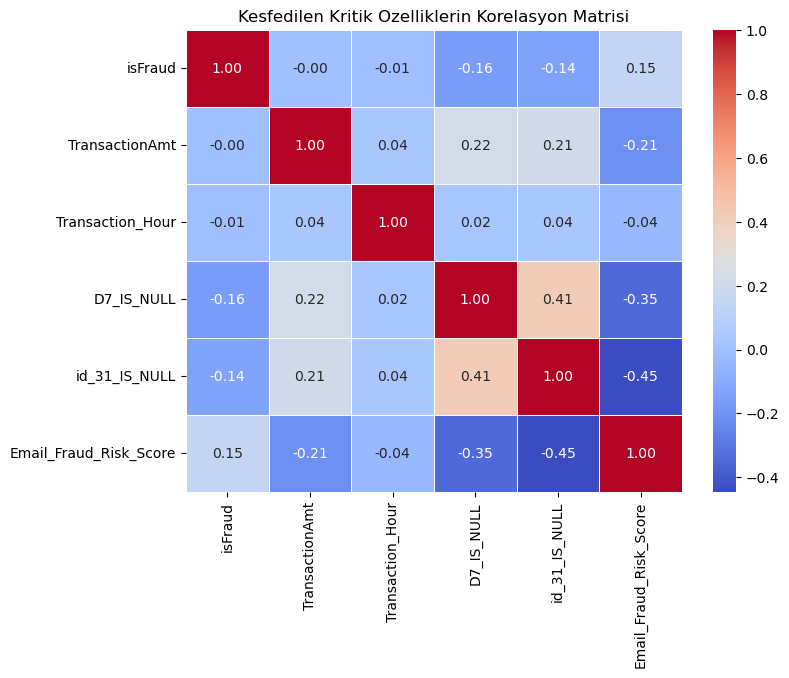

In [51]:
#Yukarida kesfettigimiz en guclu sinyalleri bir araya getirip korelasyonlarina bakalim

selected_features = [
    'isFraud', 'TransactionAmt', 'Transaction_Hour', 
    'D7_IS_NULL', 'id_31_IS_NULL', 'Email_Fraud_Risk_Score'
]

df['Transaction_Hour'] = ((df['TransactionDT'] / 3600) % 24).astype(int)
df['D7_IS_NULL'] = df['D7'].isnull().astype(int)
df['id_31_IS_NULL'] = df['id_31'].isnull().astype(int)

email_fraud_means = df.groupby('R_emaildomain')['isFraud'].transform('mean')
df['Email_Fraud_Risk_Score'] = email_fraud_means.fillna(df['isFraud'].mean())

plt.figure(figsize=(8, 6))
sns.heatmap(df[selected_features].corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Kesfedilen Kritik Ozelliklerin Korelasyon Matrisi')
plt.show()

## Modelleme ve Validation Stratejisi
#### Veri seti zamansal bir sureklilik icerdigi icin rastgele bolme yapilmayacaktir. Verinin ilk %70lik kronolojik kismi train sonraki %15 validation ve son %15 ise test seti olarak ayrilacaktir.

#### Kategoruk degisken yonetimi ve sinif dengelenmesinde yapilacaklar yukarida not edilmistir.

In [61]:
''' Datayi zamansal ayirirken en onemli sorunlardan biri zaman bazli sinif dagilim oranidir. 
Yani Train setindeki fraud orani %3.8ken test setinde bu oran %1'e dusebilir ya da %7'ye firlayabilir. 
Bu yuzden zamansal dagilimi manuel kontrol edelim
'''

df = df.sort_values('TransactionDT').reset_index(drop=True)

n = len(df)
train_idx = int(n * 0.70)
val_idx = int(n * 0.85)

train_df = df.iloc[:train_idx]
val_df = df.iloc[train_idx:val_idx]
test_df = df.iloc[val_idx:]

print(f"Train Fraud orani:      %{train_df['isFraud'].mean()*100:.2f}  (Satır Sayısı: {len(train_df)})")
print(f"Validation Fraud orani: %{val_df['isFraud'].mean()*100:.2f}  (Satır Sayısı: {len(val_df)})")
print(f"Test Fraud orani:       %{test_df['isFraud'].mean()*100:.2f}  (Satır Sayısı: {len(test_df)})")

Train Fraud orani:      %3.52  (Satır Sayısı: 413378)
Validation Fraud orani: %3.43  (Satır Sayısı: 88581)
Test Fraud orani:       %3.48  (Satır Sayısı: 88581)


Zamansal bolme yapmamiza ragmen oranlar neredeyse birbiriyle ayni kalmis yani Veride cok radikal bir Concept Drift simdilik gorunmuyor. Ama bu ileride olmayacagi anlamina gelmez. Bu yuzden

1- PR-AUC birinci metrik yapmali ve izlemeliyiz cunku ROC-AUC kaymayi gizler ama PR-AUC fraud orani dustugu an asagi cakilarak bize alarm verir. 

2- Production ortaminda Data Drift Monitoring altyapisi kurulabilir